In [2]:
from pathlib import Path
from IPython.display import Image, display
from PIL import Image
import math

import pandas as pd
import matplotlib.pyplot as plt
import os

# Etape 1 : Importer et explorer les données

In [3]:
DATA_ROOT = Path("data") / "mri_dataset_brain_cancer_oc"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

records = []

def add_record(image_path, subset_name, label=None):
    records.append(
        {
            "filepath": str(image_path.resolve()),
            "filename": image_path.name,
            "source_path": str(image_path.parent.resolve()),
            "label": label,
            "subset": subset_name,
        }
    )

# Sous-ensemble fortement labellisé: attendu en arborescence avec_labels/<label>/image
labeled_root = DATA_ROOT / "avec_labels"
for label_dir in labeled_root.iterdir():
    if not label_dir.is_dir():
        continue

    label_name = label_dir.name
    for image_path in label_dir.rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            add_record(image_path, subset_name="avec_labels", label=label_name)

# Sous-ensemble faiblement labellisé: images directement dans sans_label
unlabeled_root = DATA_ROOT / "sans_label"
for image_path in unlabeled_root.rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
        add_record(image_path, subset_name="sans_label", label=None)

df = pd.DataFrame(records)
df.head()
df.describe(include="all")

df[['subset']]


,subset
0,avec_labels
1,avec_labels
2,avec_labels
3,avec_labels
4,avec_labels
...,...
1501,sans_label
1502,sans_label
1503,sans_label
1504,sans_label


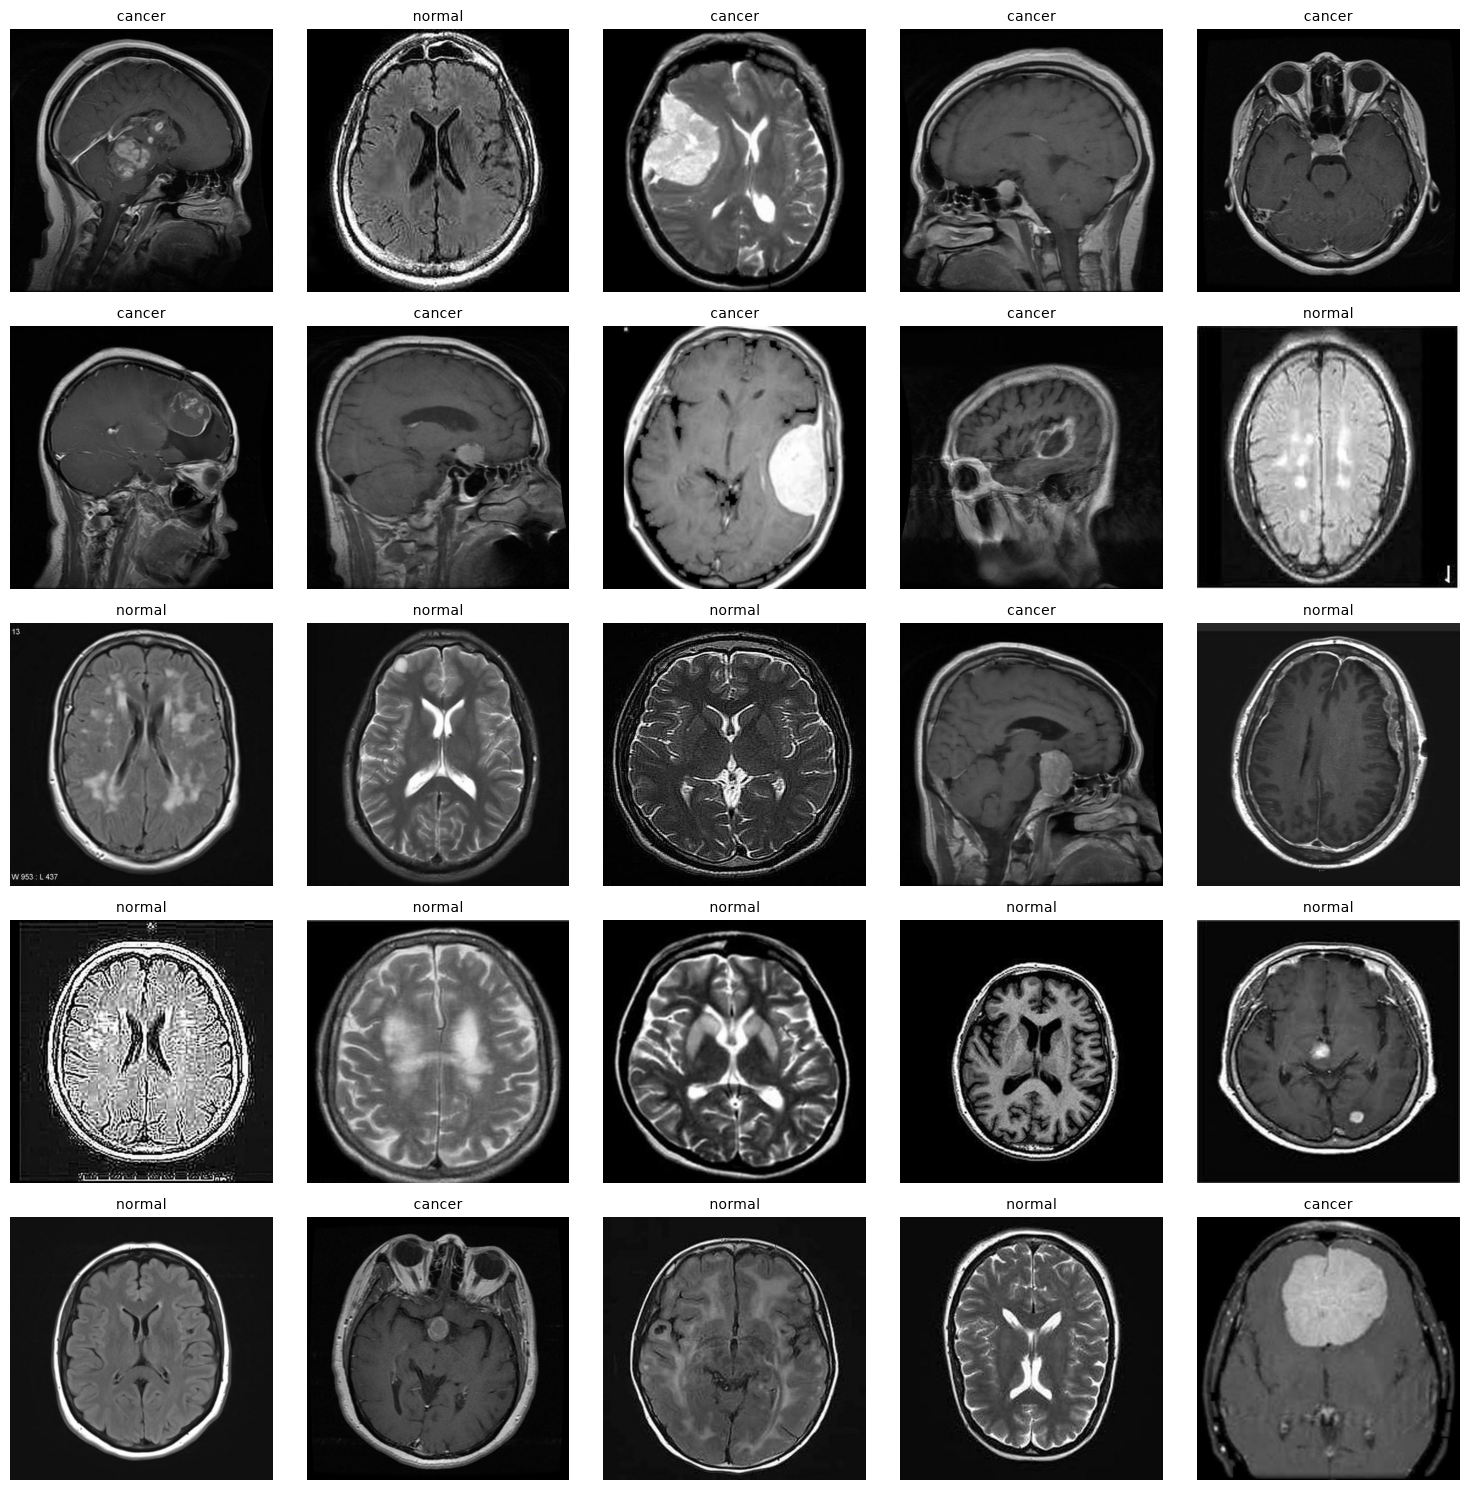

In [4]:
# 1. Configuration de la grille (5 lignes, 5 colonnes = 25 images)
n_rows = 5
n_cols = 5
num_examples = n_rows * n_cols

# 2. Filtrage et sélection aléatoire
df_filtered = df[df['subset'] == 'avec_labels']
num_examples = min(num_examples, len(df_filtered))
df_random = df_filtered.sample(n=num_examples)

# Recalculer le nombre de lignes nécessaire si le dataset est trop petit
n_rows = math.ceil(num_examples / n_cols)

# 3. Création de la figure (ajustement de la taille de la figure en hauteur)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))

# Forcer 'axes' à être une liste à 1 dimension pour pouvoir boucler facilement dessus
axes = axes.flatten()

# 4. Boucle d'affichage
for i in range(num_examples):
    try:
        img_path = df_random.iloc[i]['filepath']
        label = df_random.iloc[i]['label']
        
        image = Image.open(img_path)
        axes[i].imshow(image)
        axes[i].set_title(label, fontsize=10)
        axes[i].axis("off")

    except Exception as e:
        print(f"Erreur à l'index {i} ({img_path}): {e}")
        axes[i].axis("off")

# 5. Masquer les cases vides si le dataset avait moins d'images que prévu
for j in range(num_examples, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [5]:
corrupted_files = []
valid_metadata = []

print("--- VÉRIFICATION DE L'INTÉGRITÉ DES IMAGES ---")

# On parcourt le dataset pour tester l'ouverture des fichiers
for idx, row in df.iterrows():
    path = row['filepath']
    try:
        with Image.open(path) as img:
            img.verify() # Vérifie l'intégrité sans charger toute l'image en mémoire
        
        # Si valide, on recharge proprement pour extraire les dimensions et canaux
        with Image.open(path) as img:
            valid_metadata.append({
                'index': idx,
                'width': img.width,
                'height': img.height,
                'mode': img.mode, # RGB, RGBA, L (niveaux de gris)
                'format_physique': img.format # JPEG, PNG, etc.
            })
    except Exception as e:
        corrupted_files.append((path, str(e)))

print(f"Nombre d'images corrompues/introuvables : {len(corrupted_files)}")
if corrupted_files:
    print("Exemples de fichiers problématiques :")
    for p, err in corrupted_files[:5]:
        print(f"- {p} -> Erreur : {err}")


--- VÉRIFICATION DE L'INTÉGRITÉ DES IMAGES ---
Nombre d'images corrompues/introuvables : 0


## Analyse des dimensions et résolutions

In [6]:
if valid_metadata:
    df_meta = pd.DataFrame(valid_metadata)
    
    print("\n--- ANALYSE DES DIMENSIONS ET RÉSOLUTIONS ---")
    # Statistiques sur la largeur et la hauteur
    print(df_meta[['width', 'height']].describe())
    
    # Résolution (Ratio Largeur/Hauteur) pour détecter les images étirées
    df_meta['aspect_ratio'] = df_meta['width'] / df_meta['height']
    print("\nStatistiques du Ratio d'aspect (Width/Height) :")
    print(df_meta['aspect_ratio'].describe())
    
    print("\n--- ANALYSE DES CANAUX ET FORMATS REELS ---")
    # Modes de couleur : RGB (3 canaux), RGBA (4 canaux), L (1 canal / Noir et blanc)
    print("Modes de couleurs réels des images :")
    print(df_meta['mode'].value_counts())
    
    print("\nFormats d'encodage réels des images :")
    print(df_meta['format_physique'].value_counts())
else:
    print("Aucune image valide analysée.")


--- ANALYSE DES DIMENSIONS ET RÉSOLUTIONS ---
        width  height
count  1506.0  1506.0
mean    512.0   512.0
std       0.0     0.0
min     512.0   512.0
25%     512.0   512.0
50%     512.0   512.0
75%     512.0   512.0
max     512.0   512.0

Statistiques du Ratio d'aspect (Width/Height) :
count    1506.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64

--- ANALYSE DES CANAUX ET FORMATS REELS ---
Modes de couleurs réels des images :
mode
RGB    1506
Name: count, dtype: int64

Formats d'encodage réels des images :
format_physique
JPEG    1506
Name: count, dtype: int64


L'ensemble du jeu de données est bien redimensionnées en 512×512 pixels.

# Etape 2 : Extraire des embeddings visuels

In [7]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm

## Configuration et Préparation des Données

In [ ]:
# Sélection du processeur (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du périphérique : {device}")

# IMPORTANT: pour le semi-supervisé, on garde tout le dataset
# (avec_labels + sans_label) afin d'extraire des embeddings pour les 2 subsets.
df_work = df.reset_index(drop=True)

# Définition des transformations standards pour ResNet (ImageNet)
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),               # Taille requise par ResNet
    transforms.ToTensor(),                       # Conversion en tenseur PyTorch [0, 1]
    transforms.Normalize(                        # Normalisation ImageNet (Moyenne & Écart-type)
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

# Création d'un Dataset PyTorch personnalisé pour lire les images efficacement
class ImageEmbeddingDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

        # Compatibilité avec les API qui attendent `dataset.labels` et `info['label']`
        if 'label' in self.df.columns:
            known_labels = sorted(self.df['label'].dropna().astype(str).unique().tolist())
            self.label_to_idx = {label_name: i for i, label_name in enumerate(known_labels)}
            self.labels = np.array(
                [self.label_to_idx.get(str(v), -1) if pd.notna(v) else -1 for v in self.df['label']],
                dtype=np.int64
            )
            self.info = {'label': {str(i): label_name for label_name, i in self.label_to_idx.items()}}
        else:
            self.label_to_idx = {}
            self.labels = np.full(len(self.df), -1, dtype=np.int64)
            self.info = {'label': {}}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        try:
            # Ouverture et conversion forcée en RGB (3 canaux)
            with Image.open(img_path) as img:
                img = img.convert('RGB')
                return self.transform(img), idx, True
        except Exception:
            # En cas d'erreur sur l'image, on retourne un tenseur vide
            return torch.zeros(3, 224, 224), idx, False

# Initialisation du DataLoader pour charger les images par lots (Batchs)
dataset = ImageEmbeddingDataset(df_work, transform=transform_pipeline)

# Creation des jeux de données
# 1) Jeu labellisé seulement
df_labeled = df_work[df_work['subset'] == 'avec_labels'].copy().reset_index(drop=True)
# 2)Jeu de données sans label
df_unlabeled = df_work[df_work['subset'] == 'sans_label'].copy()

# 3) Encodage des labels
label_to_idx = {label: i for i, label in enumerate(sorted(df_labeled['label'].unique()))}
df_labeled['label_code'] = df_labeled['label'].map(label_to_idx)

# 4) Split train/test sur le jeu labellisé
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_labeled,
    test_size=0.2,
    stratify=df_labeled['label'],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_dataset = ImageEmbeddingDataset(train_df, transform=transform_pipeline)
test_dataset = ImageEmbeddingDataset(test_df, transform=transform_pipeline)

info = train_dataset.info
dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

Utilisation du périphérique : cpu


In [9]:
print(len(dataset))
print(len(train_dataset))
print(len(test_df))

1506
80
20


## Chargement du Modèle et Configuration

In [ ]:
# Charger un modèle ResNet50 pré-entraîné
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = torch.nn.Identity()

# Basculer le modèle en mode évaluation
model.eval()
model = model.to(device)

## Boucle d'Extraction des Embeddings

In [11]:
all_embeddings = []
valid_indices = []

print("Extraction des features en cours...")
with torch.no_grad(): # Désactive le calcul des gradients pour économiser la mémoire
    for imgs, idxs, status in tqdm(dataloader):
        # Filtrer uniquement les images qui ont réussi à charger
        valid_mask = status == True
        if not valid_mask.any():
            continue
            
        imgs = imgs[valid_mask].to(device)
        idxs = idxs[valid_mask]
        
        # Passage dans le modèle pour obtenir les features
        features = model(imgs)
        
        # Stockage sous forme de tableau NumPy
        all_embeddings.append(features.cpu().numpy())
        valid_indices.extend(idxs.tolist())

# Fusion de tous les batchs en une seule matrice NumPy
features_matrix = np.vstack(all_embeddings)
print(f"Forme de la matrice finale : {features_matrix.shape}") 
# Résultat attendu : (Nombre d'images valides, 2048)

Extraction des features en cours...


100%|██████████| 48/48 [01:08<00:00,  1.42s/it]

Forme de la matrice finale : (1506, 2048)


## Sauvegarde dans un Tableau Exploitable

In [ ]:
# Sauvegarde brute au format NumPy
np.save('images_embeddings.npy', features_matrix)

# Liaison avec le DataFrame Pandas d'origine
df_features = df_work.iloc[valid_indices].copy()
# Créer une liste de vecteurs dans une seule colonne Pandas
df_features['embedding'] = list(features_matrix)
df_features.to_pickle('df_with_embeddings.pkl') # Sauvegarde au format pickle pour conserver les listes

print("Sauvegarde effectuée avec succès !")

Sauvegarde effectuée avec succès !


# Etape 3 : Analyse non supervisé

## ALIGNEMENT ET SÉPARATION DES DONNÉES (FORT VS FAIBLE)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, roc_auc_score, accuracy_score, f1_score

# Filtre pour le jeu fortement labellisé
mask_fort = df_features['subset'] == 'avec_labels'
df_fort = df_features[mask_fort].copy().reset_index(drop=True)
X_fort = features_matrix[mask_fort]
y_true_fort = df_fort['label'].astype('category').cat.codes.values # Encodage 0/1 pour l'ARI

# Filtre pour le jeu faiblement labellisé (sans labels d'origine)
mask_faible = df_features['subset'] == 'sans_label'
df_faible = df_features[mask_faible].copy().reset_index(drop=True)
X_faible = features_matrix[mask_faible]

df_features.describe()

,filepath,filename,source_path,label,subset,embedding
count,1506,1506,1506,100,1506,1506
unique,1506,1506,3,2,2,1506
top,C:\Formation\Projet_10\data\mri_dataset_brain_...,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,C:\Formation\Projet_10\data\mri_dataset_brain_...,cancer,sans_label,"[0.011641124, 0.01485502, 0.30946934, 0.112983..."
freq,1,1,1406,50,1406,1


## STANDARDISATION ET RÉDUCTION DE DIMENSION (PCA)

In [14]:
# Recommandation : Standardisation
scaler = StandardScaler()
X_fort_scaled = scaler.fit_transform(X_fort)
if len(X_faible) > 0 :
    X_faible_scaled = scaler.transform(X_faible)

# PCA pour la visualisation 2D
pca = PCA(n_components=2, random_state=42)
X_fort_pca = pca.fit_transform(X_fort_scaled)
if len(X_faible) > 0 :
    X_faible_pca = pca.transform(X_faible_scaled)

## COMPARAISON DE DEUX MÉTHODES DE CLUSTERING (SUR LE JEU FORT)

In [ ]:
# Méthode 1 : K-Means (Contrainte : 2 clusters)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_fort_kmeans = kmeans.fit_predict(X_fort_scaled)
ari_kmeans = adjusted_rand_score(y_true_fort, clusters_fort_kmeans)

# Méthode 2 : Clustering Hiérarchique (Contrainte : 2 clusters, alternative à DBSCAN)
# Justification : DBSCAN trouve un nombre de clusters variable et génère du bruit (-1).
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
clusters_fort_hc = hc.fit_predict(X_fort_scaled)
ari_hc = adjusted_rand_score(y_true_fort, clusters_fort_hc)

print("--- ÉVALUATION DES MÉTHODES (JEU FORT) ---")
print(f"Score ARI avec K-Means : {ari_kmeans:.4f}")
print(f"Score ARI avec Clustering Hiérarchique : {ari_hc:.4f}\n")

--- ÉVALUATION DES MÉTHODES (JEU FORT) ---
Score ARI avec K-Means : 0.2854
Score ARI avec Clustering Hiérarchique : 0.7721



## APPLICATION DE LA MEILLEURE MÉTHODE SUR LE JEU FAIBLE

In [ ]:
# Vérification avant clustering faible
if len(X_faible) == 0:
    print("Aucune donnée dans le jeu faible : pas de labellisation faible.")
    df_faible['weak_label'] = pd.Series(dtype='int64')
else:
    # Standardisation 
    X_faible_scaled = scaler.transform(X_faible)

    # On sélectionne le modèle qui a obtenu le meilleur score ARI
    if ari_kmeans >= ari_hc:
        print("-> K-Means sélectionné pour la labellisation faible.")
        clusters_faible = kmeans.predict(X_faible_scaled)
    else:
        print("-> Clustering Hiérarchique sélectionné pour la labellisation faible.")
        clusters_faible = hc.fit_predict(X_faible_scaled) # TODO : vérifier l'indexation des clusters

    df_faible['weak_label'] = clusters_faible

-> Clustering Hiérarchique sélectionné pour la labellisation faible.


## VISUALISATION DES RÉSULTATS (GRAPHES 2D)

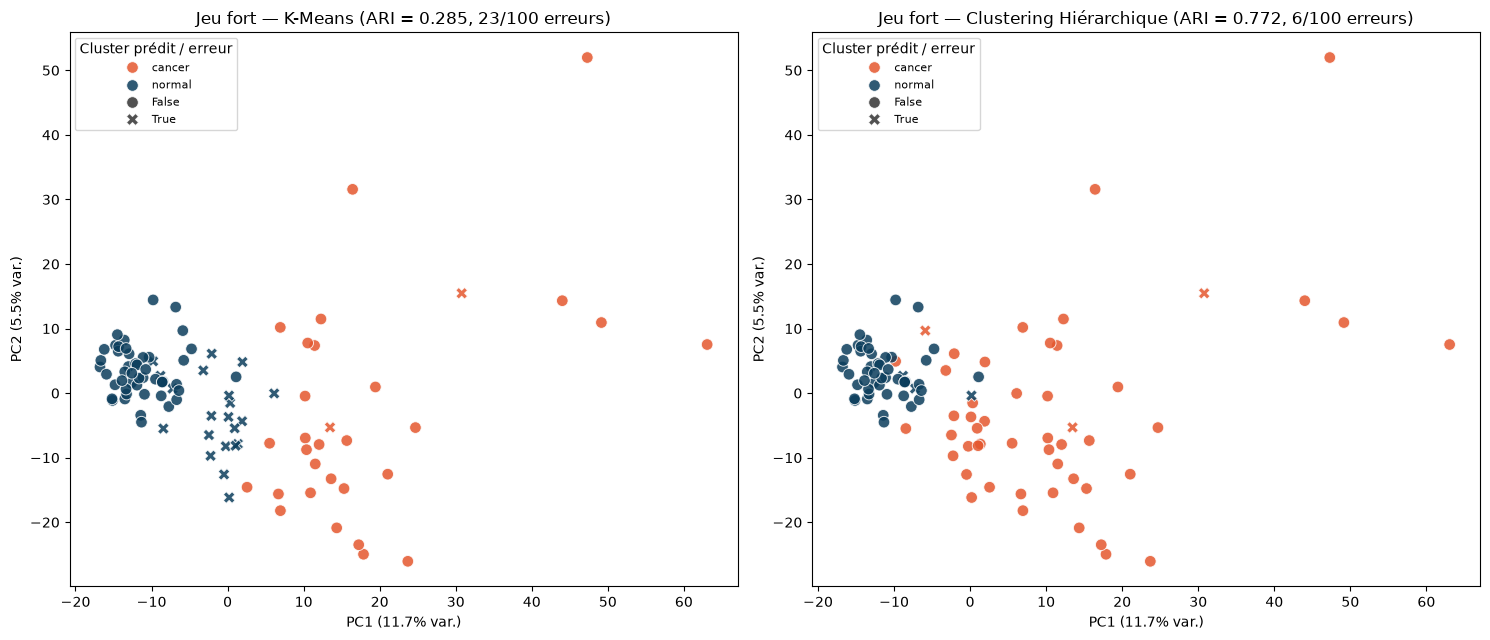

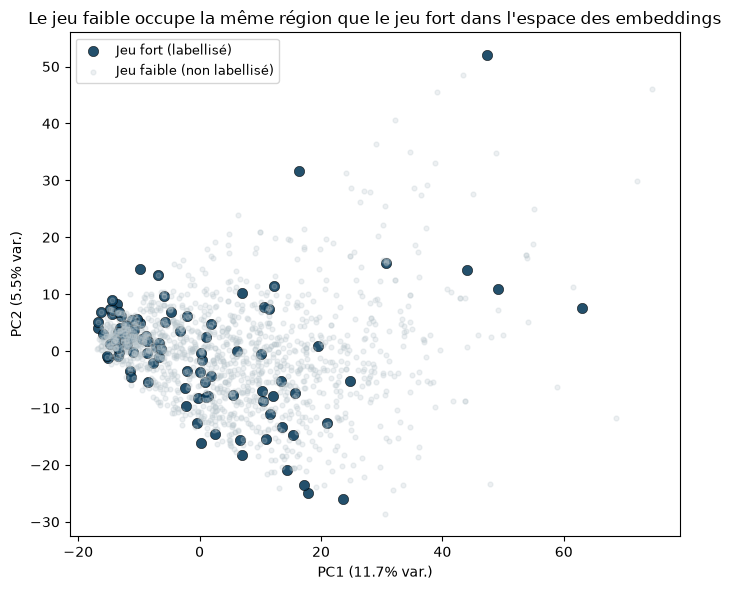

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

plot_fort(axes[0], pred_kmeans, erreurs_kmeans, ari_kmeans, "K-Means")
plot_fort(axes[1], pred_hc, erreurs_hc, ari_hc, "Clustering Hiérarchique")

var_ratio = pca.explained_variance_ratio_
for a in axes:
    a.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}% var.)")
    a.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}% var.)")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_fort_pca[:, 0], X_fort_pca[:, 1], c='#0B3D5C', s=55,
           edgecolor='black', linewidth=0.4, alpha=0.9, label='Jeu fort (labellisé)')
if len(X_faible) > 0:
    ax.scatter(X_faible_pca[:, 0], X_faible_pca[:, 1], c='#B9C6CC', s=12,
               alpha=0.25, label='Jeu faible (non labellisé)')
ax.set_title("Le jeu faible occupe la même région que le jeu fort dans l'espace des embeddings")
ax.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}% var.)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Etape 4 : Entraînement CNN — Comparaison Supervisé vs Semi-Supervisé

### pseudo-labellisation

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression


X_fort = np.stack(df_fort['embedding'].values)
y_fort = df_fort['label'].astype('category').cat.codes.values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = cross_val_score(LogisticRegression(max_iter=1000), X_fort, y_fort, cv=cv, scoring='roc_auc')
print(f"AUC moyen (5-fold) : {aucs.mean():.3f} ± {aucs.std():.3f}")

AUC moyen (5-fold) : 0.964 ± 0.022


In [44]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Séparation des deux sous-ensembles
df_fort   = df_features[df_features['subset'] == 'avec_labels'].copy()
df_faible = df_features[df_features['subset'] == 'sans_label'].copy()

# Split train/test UNIQUEMENT sur les données labellisées (le pool non labellisé n'y touche jamais)
train_df, test_df = train_test_split(
    df_fort, test_size=0.5, stratify=df_fort['label'], random_state=42
)

X_train = np.stack(train_df['embedding'].values)
y_train = train_df['label'].astype('category').cat.codes.values

X_test = np.stack(test_df['embedding'].values)
y_test = test_df['label'].astype('category').cat.codes.values

X_unlabeled = np.stack(df_faible['embedding'].values)

# SelfTrainingClassifier attend -1 pour les exemples non labellisés
X_ssl = np.vstack([X_train, X_unlabeled])
y_ssl = np.concatenate([y_train, np.full(len(X_unlabeled), -1)])

base_clf = LogisticRegression(max_iter=1000, class_weight={0: 3, 1: 1})
ssl_clf = SelfTrainingClassifier(base_clf, threshold=0.98, max_iter=30, verbose=True)
ssl_clf.fit(X_ssl, y_ssl)

# Évaluation sur le jeu de test, jamais vu ni en train ni en pseudo-labellisation
y_pred  = ssl_clf.predict(X_test)
y_proba = ssl_clf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')
recall_cancer = recall_score(y_test, y_pred, pos_label=0, average='binary')

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['cancer', 'normal'], digits=3))

print(f"AUC: {auc:.3f}, Accuracy: {acc:.3f}, F1: {f1:.3f}, Recall cancer: {recall_cancer:.3f}")
print(f"Itérations effectuées : {ssl_clf.n_iter_}")
n_pseudo = (ssl_clf.transduction_[len(X_train):] != -1).sum()
print(f"Images pseudo-labellisées : {n_pseudo} / {len(X_unlabeled)}")

End of iteration 1, added 769 new labels.
End of iteration 2, added 299 new labels.
End of iteration 3, added 89 new labels.
End of iteration 4, added 33 new labels.
End of iteration 5, added 18 new labels.
End of iteration 6, added 16 new labels.
End of iteration 7, added 7 new labels.
End of iteration 8, added 4 new labels.
End of iteration 9, added 2 new labels.
End of iteration 10, added 4 new labels.
End of iteration 11, added 5 new labels.
End of iteration 12, added 3 new labels.
End of iteration 13, added 2 new labels.
End of iteration 14, added 1 new labels.
              precision    recall  f1-score   support

      cancer      0.885     0.920     0.902        25
      normal      0.917     0.880     0.898        25

    accuracy                          0.900        50
   macro avg      0.901     0.900     0.900        50
weighted avg      0.901     0.900     0.900        50

AUC: 0.947, Accuracy: 0.900, F1: 0.900, Recall cancer: 0.920
Itérations effectuées : 15
Images pseud

In [ ]:
import numpy as np
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Graphe construit sur train + non labellisé uniquement (test totalement à l'écart, comme pour le SelfTrainingClassifier)
X_graph = np.vstack([X_train, X_unlabeled])
y_graph = np.concatenate([y_train, np.full(len(X_unlabeled), -1)])

label_prop = LabelSpreading(kernel='knn', n_neighbors=7, alpha=0.2, max_iter=1000)
label_prop.fit(X_graph, y_graph)

# Évaluation sur le jeu de test, hors du graphe
y_pred  = label_prop.predict(X_test)
y_proba = label_prop.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')
recall_cancer = recall_score(y_test, y_pred, pos_label=0, average='binary')
print(f"AUC: {auc:.3f}, Accuracy: {acc:.3f}, F1: {f1:.3f}, Recall: {recall_cancer:.3f}")

print(classification_report(y_test, y_pred, target_names=['cancer', 'normal'], digits=3))

# Labels propagés sur le pool non labellisé
proba_unlabeled = label_prop.label_distributions_[len(X_train):]
n_confident = (proba_unlabeled.max(axis=1) > 0.9).sum()
print(f"Images avec un label propagé confiant (>0.9) : {n_confident} / {len(X_unlabeled)}")

AUC: 0.933, Accuracy: 0.900, F1: 0.900, Recall: 0.867
              precision    recall  f1-score   support

      cancer      0.929     0.867     0.897        15
      normal      0.875     0.933     0.903        15

    accuracy                          0.900        30
   macro avg      0.902     0.900     0.900        30
weighted avg      0.902     0.900     0.900        30

Images avec un label propagé confiant (>0.9) : 1279 / 1406
Seuil nécessaire pour recall >= 0.95 : 0.000
Précision à ce seuil : 0.500
